In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10

In [2]:
sql= "select * from acc_ord_card_disp_client_dist aocdcd join loan_trans lt on lt.account_id= aocdcd.account_id" 

In [5]:
import mysql.connector as connection
try:
    mydb = connection.connect(host="localhost", database = 'capstone_prj', user="root", passwd="Rohan@777",use_pure=True)
    df = pd.read_sql(sql,mydb)
    mydb.close() #close the connection
except Exception as e:
    mydb.close()
    print(str(e))

C:\Users\ROHAN\AppData\Local\Temp\ipykernel_22876\2325888468.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql,mydb)


In [6]:
df

,card_id,disp_id,type,issued,account_id,disposition_client_id,disposition_type,client_id,birth_number,district_id,...,balance,k_symbol,bank,account,loan_id,loan_date,loan_amount,duration,payments,status
0,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19916.6,UROK,,,5325,930803,105804,36,2939.0,A
1,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,26099.1,,,,5325,930803,105804,36,2939.0,A
2,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19799.1,,,,5325,930803,105804,36,2939.0,A
3,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,24499.1,SIPO,QR,62958741,5325,930803,105804,36,2939.0,A
4,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,31493.1,UVER,QR,70984434,5325,930803,105804,36,2939.0,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1036,9735,classic,970117 00:00:00,8129,10043,OWNER,10043,651029,45,...,700.0,,,,6668,940730,74736,36,2076.0,A
864,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,54840.0,,GH,84269058,6678,940520,80340,12,6695.0,A
865,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,14000.0,,,,6678,940520,80340,12,6695.0,A
866,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,1100.0,,,,6678,940520,80340,12,6695.0,A


In [7]:
df.status.value_counts()

status
A    648
B    168
C     51
D      1
Name: count, dtype: int64

In [8]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df.iloc[:,-1]=le.fit_transform(df.iloc[:,-1])
df

,card_id,disp_id,type,issued,account_id,disposition_client_id,disposition_type,client_id,birth_number,district_id,...,balance,k_symbol,bank,account,loan_id,loan_date,loan_amount,duration,payments,status
0,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19916.6,UROK,,,5325,930803,105804,36,2939.0,0
1,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,26099.1,,,,5325,930803,105804,36,2939.0,0
2,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,19799.1,,,,5325,930803,105804,36,2939.0,0
3,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,24499.1,SIPO,QR,62958741,5325,930803,105804,36,2939.0,0
4,352,2235,classic,980911 00:00:00,1843,2235,OWNER,2235,405420,14,...,31493.1,UVER,QR,70984434,5325,930803,105804,36,2939.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
863,1036,9735,classic,970117 00:00:00,8129,10043,OWNER,10043,651029,45,...,700.0,,,,6668,940730,74736,36,2076.0,0
864,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,54840.0,,GH,84269058,6678,940520,80340,12,6695.0,0
865,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,14000.0,,,,6678,940520,80340,12,6695.0,0
866,1038,9787,junior,950330 00:00:00,8173,10095,OWNER,10095,765206,1,...,1100.0,,,,6678,940520,80340,12,6695.0,0


In [9]:
df.status.value_counts()

status
0    648
1    168
2     51
3      1
Name: count, dtype: int64

In [10]:
x=df[['loan_amount', 'balance']].values
x

array([[105804. ,  19916.6],
       [105804. ,  26099.1],
       [105804. ,  19799.1],
       ...,
       [ 80340. ,  14000. ],
       [ 80340. ,   1100. ],
       [ 28248. ,    400. ]])

In [11]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
x=mms.fit_transform(x)
x

array([[0.28768316, 0.13748826],
       [0.28768316, 0.18060021],
       [0.28768316, 0.13666891],
       ...,
       [0.20733785, 0.09623048],
       [0.20733785, 0.0062759 ],
       [0.04297452, 0.00139464]])

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss=[]
silhouette_scores=[]
for i in range(1,15):
    kmeans=KMeans(n_clusters=i, init='k-means++', random_state=42)
    labels=kmeans.fit_predict(x)
    wcss.append(kmeans.inertia_)
    if i >= 2:
        score = silhouette_score(x, labels)
        silhouette_scores.append((i, score))
        print(f'k={i}: silhouette score = {score:.4f}')
wcss

k=2: silhouette score = 0.4336
k=3: silhouette score = 0.3984
k=4: silhouette score = 0.3690
k=5: silhouette score = 0.3957
k=6: silhouette score = 0.4426
k=7: silhouette score = 0.4497
k=8: silhouette score = 0.3927
k=9: silhouette score = 0.4140
k=10: silhouette score = 0.4328
k=11: silhouette score = 0.4375
k=12: silhouette score = 0.4341
k=13: silhouette score = 0.4463
k=14: silhouette score = 0.4491


[82.12421143832711,
 46.114887209107344,
 31.558395111985334,
 26.572727742671994,
 19.012027298105053,
 13.903501799333046,
 11.873963461110215,
 10.901057232616662,
 9.240629113114828,
 7.745877060347368,
 7.2095638881975495,
 6.727279044945192,
 5.683680286299131,
 5.161988245760233]

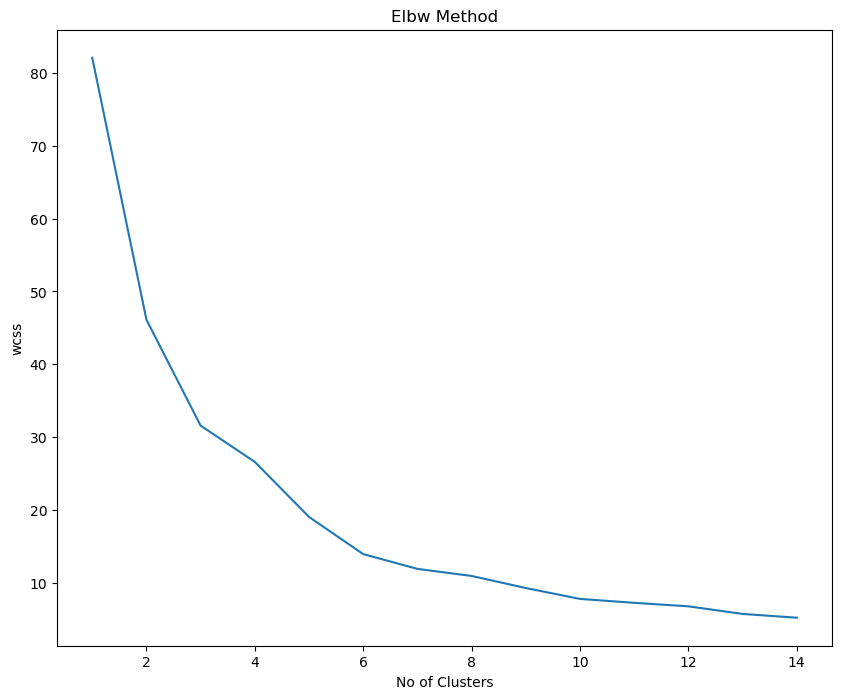

In [13]:
from matplotlib.pylab import rcParams
rcParams['figure.figsize']=10,8
plt.plot(range(1,15), wcss)
plt.title('Elbw Method')
plt.xlabel("No of Clusters")
plt.ylabel("wcss")
plt.show()

In [14]:
kmeans=KMeans(n_clusters=2, init='k-means++', random_state=42)
kmeans.fit(x)
y_kmeans=kmeans.labels_
y_kmeans

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [16]:
x_final=pd.concat([df.iloc[:,4], pd.DataFrame(x), pd.DataFrame(y_kmeans)], axis=1)
x_final.columns= ['account_id','loan_amount','balance','cluster']
x_final

,account_id,loan_amount,balance,cluster
0,1843,0.287683,0.137488,0
1,1843,0.287683,0.180600,0
2,1843,0.287683,0.136669,0
3,1843,0.287683,0.169443,0
4,1843,0.287683,0.218214,0
...,...,...,...,...
863,8129,0.189656,0.003487,0
864,8173,0.207338,0.381017,0
865,8173,0.207338,0.096230,0
866,8173,0.207338,0.006276,0


In [18]:
x_final.cluster.value_counts()

cluster
0    540
1    328
Name: count, dtype: int64

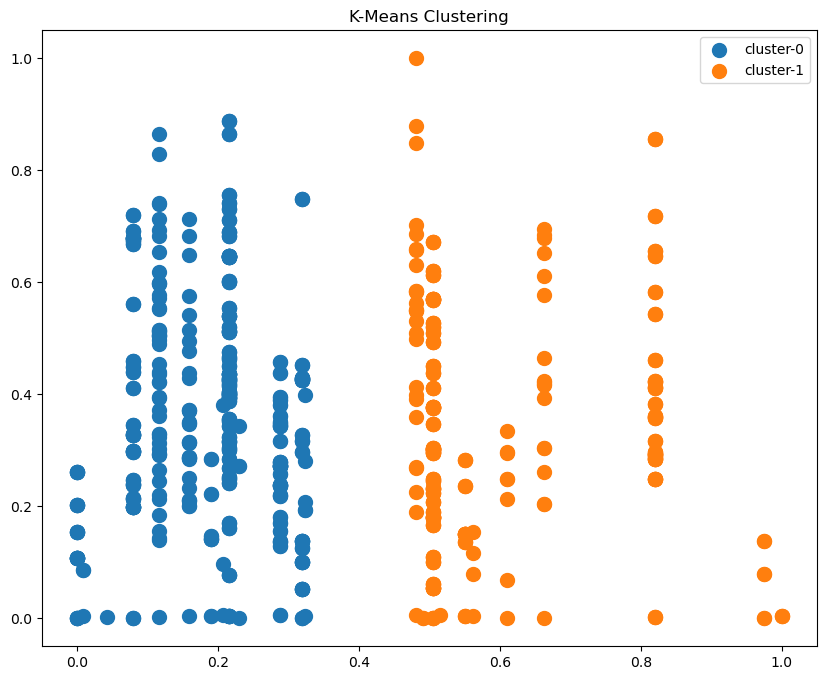

In [19]:
plt.scatter(x[y_kmeans==0,0], x[y_kmeans==0,1], s=100, label='cluster-0')
plt.scatter(x[y_kmeans==1,0], x[y_kmeans==1,1], s=100, label='cluster-1')
plt.title('K-Means Clustering')
plt.legend()
plt.show()

In [20]:
x

array([[0.28768316, 0.13748826],
       [0.28768316, 0.18060021],
       [0.28768316, 0.13666891],
       ...,
       [0.20733785, 0.09623048],
       [0.20733785, 0.0062759 ],
       [0.04297452, 0.00139464]])

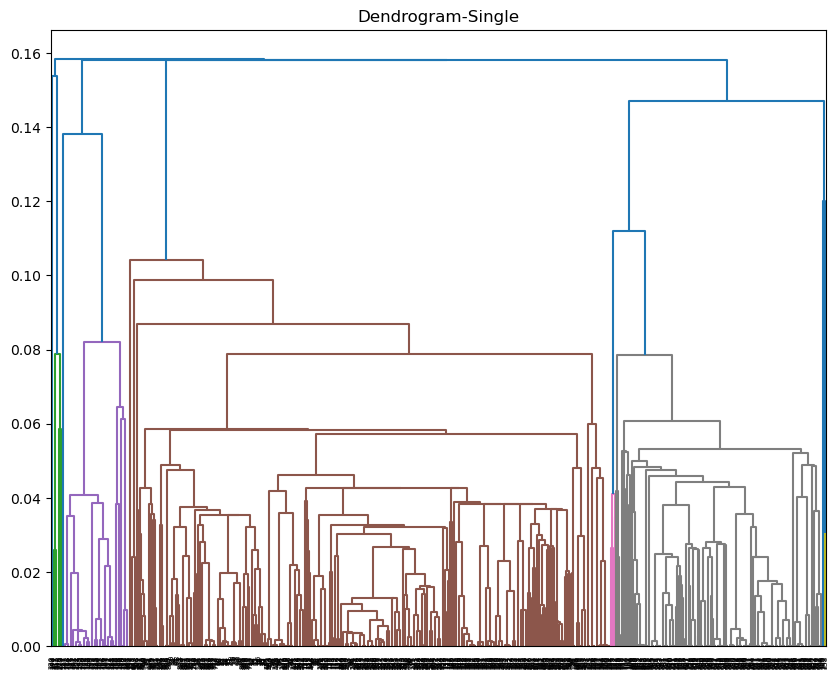

In [21]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x, method='single'))
plt.title('Dendrogram-Single')
plt.show()

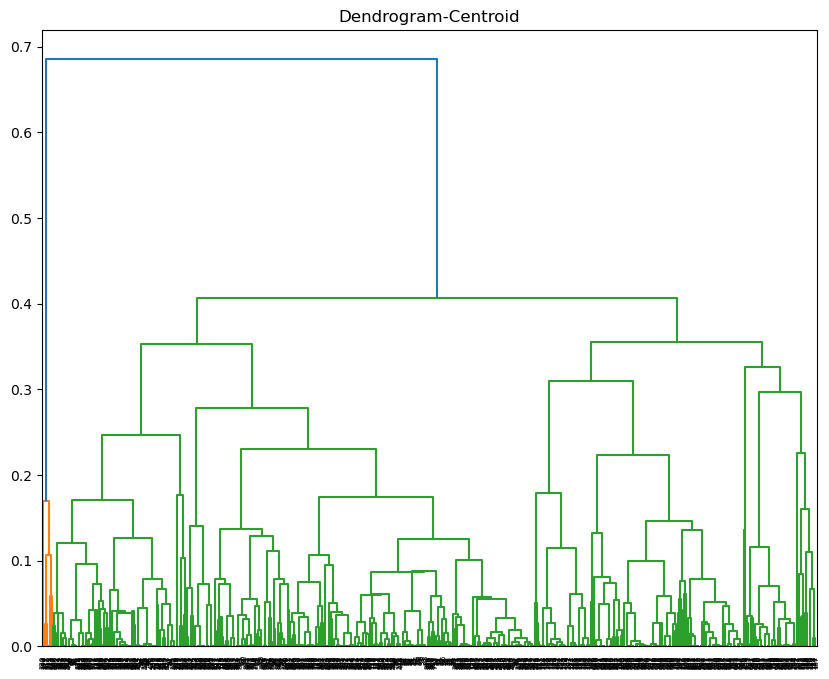

In [22]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x, method='centroid'))
plt.title('Dendrogram-Centroid')
plt.show()

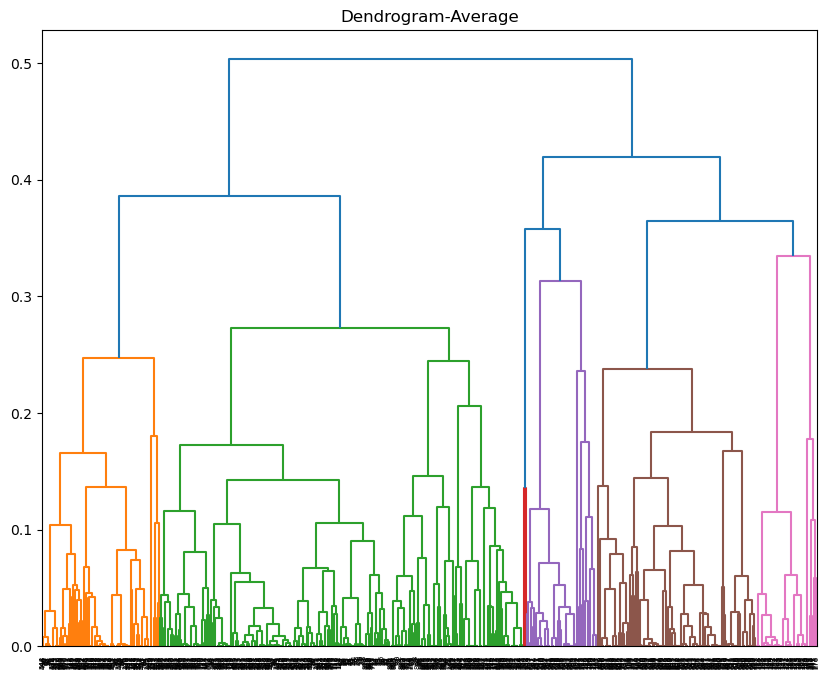

In [23]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x, method='average'))
plt.title('Dendrogram-Average')
plt.show()
                          

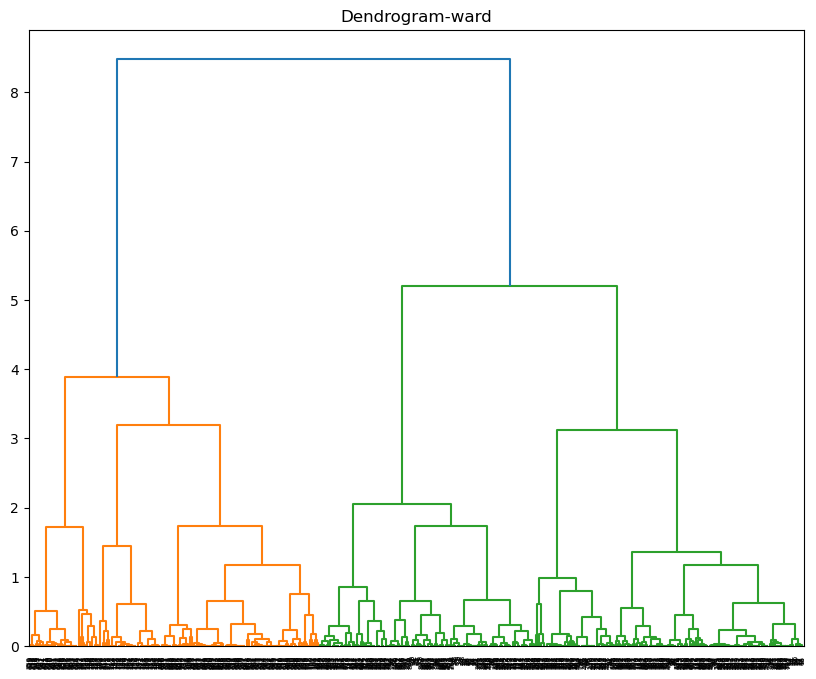

In [24]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(x, method='ward'))
plt.title('Dendrogram-ward')
plt.show()

In [25]:
from sklearn.cluster import AgglomerativeClustering
ac=AgglomerativeClustering(n_clusters=2, linkage='single')
ac_y_pred=ac.fit_predict(x)
ac_y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [27]:
pd.DataFrame(ac_y_pred).value_counts()

0
0    856
1     12
Name: count, dtype: int64

In [28]:
x_final=pd.concat([df.iloc[:,4],pd.DataFrame(x), pd.DataFrame(ac_y_pred)], axis=1)
x_final.columns=[['account_id', 'loan_amount', 'balance', 'cluster']]
x_final

,account_id,loan_amount,balance,cluster
0,1843,0.287683,0.137488,0
1,1843,0.287683,0.180600,0
2,1843,0.287683,0.136669,0
3,1843,0.287683,0.169443,0
4,1843,0.287683,0.218214,0
...,...,...,...,...
863,8129,0.189656,0.003487,0
864,8173,0.207338,0.381017,0
865,8173,0.207338,0.096230,0
866,8173,0.207338,0.006276,0


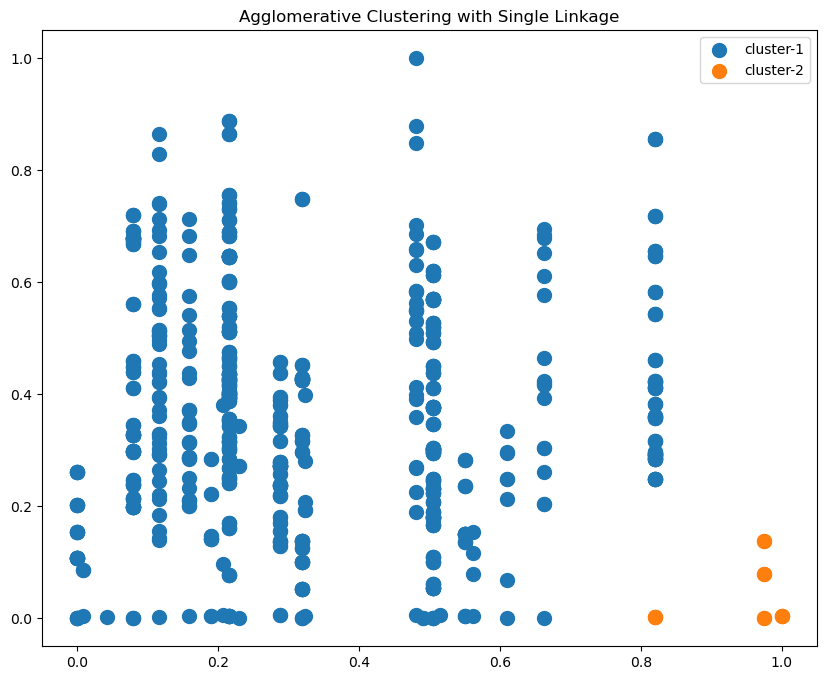

In [29]:
plt.scatter(x[ac_y_pred==0,0], x[ac_y_pred==0,1], s=100, label='cluster-1')
plt.scatter(x[ac_y_pred==1,0], x[ac_y_pred==1,1], s=100, label='cluster-2')
plt.title('Agglomerative Clustering with Single Linkage')
plt.legend()
plt.show()

In [30]:
from sklearn.cluster import AgglomerativeClustering
ac=AgglomerativeClustering(n_clusters=2, linkage='average')
ac_y_pred=ac.fit_predict(x)
ac_y_pred


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [31]:
pd.DataFrame(ac_y_pred).value_counts()

0
1    540
0    328
Name: count, dtype: int64

In [32]:
x_final=pd.concat([df.iloc[:,4], pd.DataFrame(x), pd.DataFrame(ac_y_pred)], axis=1)
x_final.columns=['account_id', 'loan_amount', 'balance', 'cluster']
x_final

,account_id,loan_amount,balance,cluster
0,1843,0.287683,0.137488,1
1,1843,0.287683,0.180600,1
2,1843,0.287683,0.136669,1
3,1843,0.287683,0.169443,1
4,1843,0.287683,0.218214,1
...,...,...,...,...
863,8129,0.189656,0.003487,1
864,8173,0.207338,0.381017,1
865,8173,0.207338,0.096230,1
866,8173,0.207338,0.006276,1


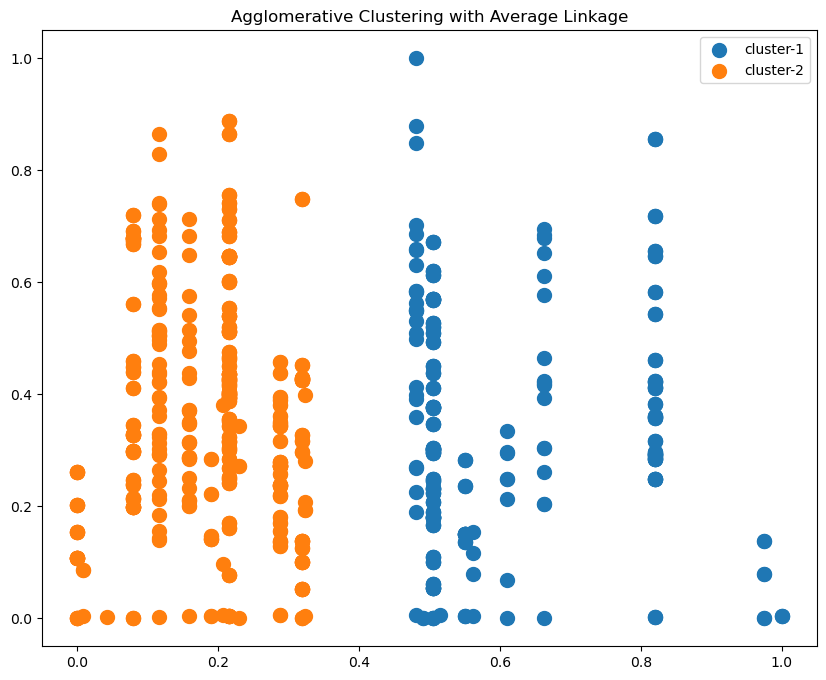

In [33]:
plt.scatter(x[ac_y_pred==0,0], x[ac_y_pred==0,1], s=100, label='cluster-1')
plt.scatter(x[ac_y_pred==1,0], x[ac_y_pred==1,1], s=100, label='cluster-2')
plt.title('Agglomerative Clustering with Average Linkage')
plt.legend()
plt.show()

In [34]:
from sklearn.cluster import AgglomerativeClustering
ac=AgglomerativeClustering(n_clusters=2, linkage='complete')
ac_y_pred=ac.fit_predict(x)
ac_y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [35]:
pd.DataFrame(ac_y_pred).value_counts()

0
0    700
1    168
Name: count, dtype: int64

In [36]:
x_final=pd.concat([df.iloc[:,4], pd.DataFrame(x), pd.DataFrame(ac_y_pred)], axis=1)
x_final.columns=['account_id', 'loan_amount', 'balance', 'cluster']
x_final

,account_id,loan_amount,balance,cluster
0,1843,0.287683,0.137488,0
1,1843,0.287683,0.180600,0
2,1843,0.287683,0.136669,0
3,1843,0.287683,0.169443,0
4,1843,0.287683,0.218214,0
...,...,...,...,...
863,8129,0.189656,0.003487,0
864,8173,0.207338,0.381017,0
865,8173,0.207338,0.096230,0
866,8173,0.207338,0.006276,0


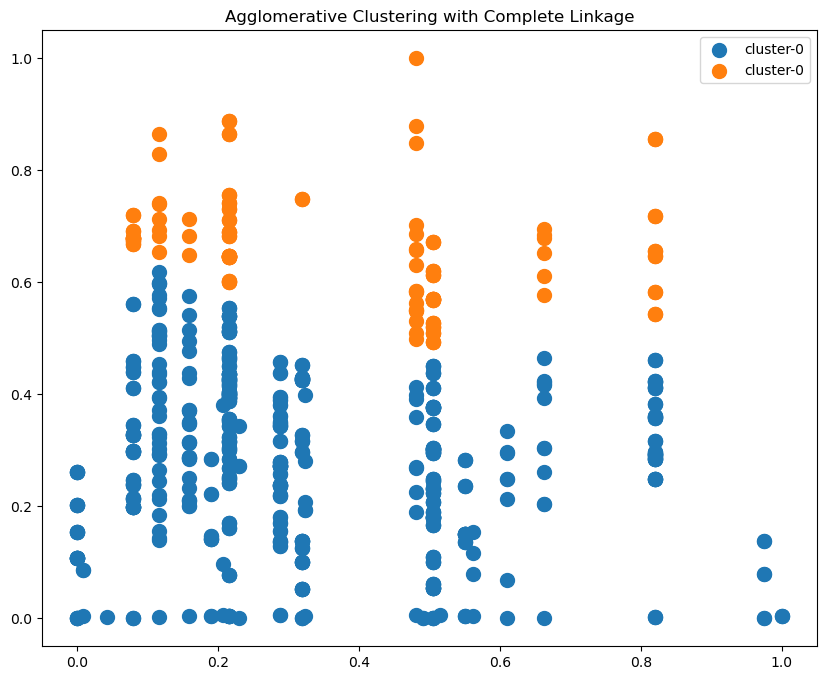

In [37]:
plt.scatter(x[ac_y_pred==0,0], x[ac_y_pred==0,1], s=100, label='cluster-0')
plt.scatter(x[ac_y_pred==1,0], x[ac_y_pred==1,1], s=100, label='cluster-0')
plt.title('Agglomerative Clustering with Complete Linkage')
plt.legend()
plt.show()

In [38]:
from sklearn.cluster import AgglomerativeClustering
ac=AgglomerativeClustering(n_clusters=2, linkage='ward')
ac_y_pred=ac.fit_predict(x)
ac_y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [39]:
pd.DataFrame(ac_y_pred).value_counts()

0
0    543
1    325
Name: count, dtype: int64

In [40]:
x_final=pd.concat([df.iloc[:,4], pd.DataFrame(x), pd.DataFrame(ac_y_pred)], axis=1)
x_final.columns=['account_id', 'loan_amount', 'balance', 'cluster']
x_final

,account_id,loan_amount,balance,cluster
0,1843,0.287683,0.137488,0
1,1843,0.287683,0.180600,0
2,1843,0.287683,0.136669,0
3,1843,0.287683,0.169443,0
4,1843,0.287683,0.218214,0
...,...,...,...,...
863,8129,0.189656,0.003487,0
864,8173,0.207338,0.381017,0
865,8173,0.207338,0.096230,0
866,8173,0.207338,0.006276,0


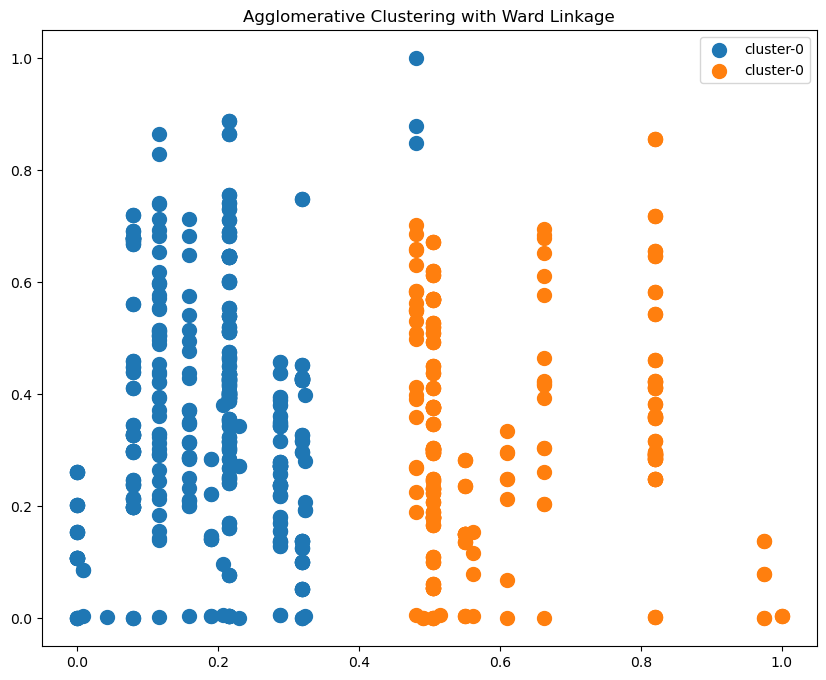

In [41]:
plt.scatter(x[ac_y_pred==0,0], x[ac_y_pred==0,1], s=100, label='cluster-0')
plt.scatter(x[ac_y_pred==1,0], x[ac_y_pred==1,1], s=100, label='cluster-0')
plt.title('Agglomerative Clustering with Ward Linkage')
plt.legend()
plt.show()